José Matheus Gonçalves Rodrigues - 2171 - GEC

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. CRIANDO O DATAFRAME PARA O EXERCÍCIO
data = {
    'id_sensor': [101, 102, 103, 104, 101, 105, 106, 107, 108, 109],
    'localizacao': ['Setor A', 'Setor B', 'Setor A', 'Setor C', 'Setor A', 'Setor B', 'Setor C', 'Setor A', np.nan, 'Setor B'],
    'consumo_kwh': [150.5, 3200.0, 150.5, 2100.0, 150.5, np.nan, 4500.0, 120.0, 5000.0, 250.0],
    'temperatura_operacao': [25.4, 65.2, 25.4, np.nan, 25.4, 40.0, 85.0, 22.0, 90.0, 30.5],
    'status': ['Ativo', 'Alerta', 'Ativo', 'Inativo', 'Ativo', 'Ativo', 'Alerta', 'Ativo', 'Critico', 'Inativo']
}

df = pd.DataFrame(data)

,id_sensor,localizacao,consumo_kwh,temperatura_operacao,status
0,101,Setor A,150.5,25.4,Ativo
1,102,Setor B,3200.0,65.2,Alerta
2,103,Setor A,150.5,25.4,Ativo
3,104,Setor C,2100.0,NaN,Inativo
4,101,Setor A,150.5,25.4,Ativo
5,105,Setor B,NaN,40.0,Ativo
6,106,Setor C,4500.0,85.0,Alerta
7,107,Setor A,120.0,22.0,Ativo
8,108,NaN,5000.0,90.0,Critico
9,109,Setor B,250.0,30.5,Inativo


Dataset original:
   id_sensor localizacao  consumo_kwh  temperatura_operacao   status
0        101     Setor A      150.500               25.4000    Ativo
1        102     Setor B     3200.000               65.2000   Alerta
2        103     Setor A      150.500               25.4000    Ativo
3        104     Setor C     2100.000               47.9375  Inativo
5        105     Setor B     1933.875               40.0000    Ativo
6        106     Setor C     4500.000               85.0000   Alerta
7        107     Setor A      120.000               22.0000    Ativo
8        108     Setor A     5000.000               90.0000  Critico
9        109     Setor B      250.000               30.5000  Inativo
Após limpeza:
   id_sensor localizacao  consumo_kwh  temperatura_operacao   status
0        101     Setor A      150.500               25.4000    Ativo
1        102     Setor B     3200.000               65.2000   Alerta
2        103     Setor A      150.500               25.4000    Ativo
3 

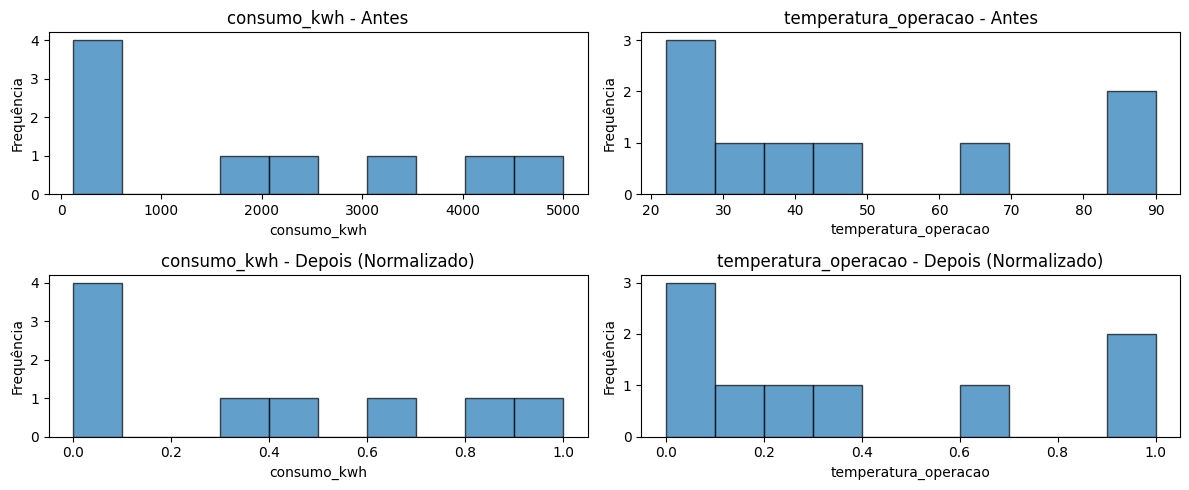

In [13]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,StandardScaler



print("Dataset original:")
print(df)


df = df.drop_duplicates()


df["localizacao"] = df["localizacao"].fillna("Setor A")
df["temperatura_operacao"] = df["temperatura_operacao"].fillna(df["temperatura_operacao"].mean())
df["consumo_kwh"] = df["consumo_kwh"].fillna(df["consumo_kwh"].mean())

print("Após limpeza:")
print(df)



df_encoded = pd.get_dummies(df, columns=["localizacao", "status","id_sensor","status"])

print("\nApós codificação:")
print(df_encoded)



colunas_para_normalizar = ["consumo_kwh", "temperatura_operacao"]

scaler = MinMaxScaler()

df_norm = df_encoded.copy()
df_norm[colunas_para_normalizar] = scaler.fit_transform(df_encoded[colunas_para_normalizar])

print("\nApós normalização:")
print(df_norm)


num_cols = ["consumo_kwh", "temperatura_operacao"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(num_cols):


    plt.subplot(2, len(num_cols), i + 1)
    plt.hist(df_encoded[col], bins=10, alpha=0.7, edgecolor='black')
    plt.title(f"{col} - Antes")
    plt.xlabel(col)
    plt.ylabel("Frequência")


    plt.subplot(2, len(num_cols), i + 1 + len(num_cols))
    plt.hist(df_norm[col], bins=10, alpha=0.7, edgecolor='black')
    plt.title(f"{col} - Depois (Normalizado)")
    plt.xlabel(col)
    plt.ylabel("Frequência")
plt.tight_layout()
plt.show()
